# **Experiment Notebook**



In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

<hr>

## A. Project


In [ ]:
student_name = 'Sonal Rao'

In [ ]:
student_id = ' 25533441'

In [ ]:
experiment_id = '4'

<hr>

## B. Experiment Description


In [ ]:
experiment_hypothesis = 'The hypothesis is that optimizing feature engineering and hyperparameters in a Decision Tree model will improve its accuracy in predicting customer churn and lead to better business outcomes.'

In [ ]:
experiment_expectations = 'The expectation is that tuning the model and refining features will increase predictive accuracy and enhance the models ability to identify churners, leading to more effective retention strategies.'

<hr>

## C. Data Understanding


### C.0 Import Packages

In [ ]:
# Pandas for data handling
import pandas as pd

# Scikit Learn for ML training
import sklearn

# Altair for plotting
import altair as alt

# Numpy for numerical operations
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report

<hr>

### C.1   Load Datasets

In [ ]:
# Load training set
# Do not change this code

X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')

In [ ]:
# Load validation set
# Do not change this code

X_val = pd.read_csv('X_val.csv')
y_val = pd.read_csv('y_val.csv')

In [ ]:
# Load testing set
# Do not change this code

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')

In [ ]:
# Saving the CSV file into DataFrame df
data = pd.read_csv('combined_dataset.csv')
df = pd.DataFrame(data)
df = df.astype({col: 'object' for col in df.select_dtypes(include=['float']).columns})

<hr>

<hr>

## D. Feature Selection


In [ ]:
feature_selection_executive_summary = 'The feature selection process identified the most relevant features, reducing dimensionality and improving model efficiency by focusing on key predictors of customer churn, such as DeviceRegistered, ParentalControl, SubscriptionType'

Rationale:

In [ ]:
# Displaying the first five rows of df
df.head()

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Aurora,Bravo,88588,Wanda Mission,Underpass,Sandyhaven,46890.0,NY,hispanic,20,...,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0,1-2-46890.0
1,Ana,María,69,Laura Gateway,Drive,DPO AA 59306,NaN,NaN,white,57,...,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0,1-3-nan
2,Susan,Lambert,81311,Hunter Fort,Cove,South Sarahshire,12793.0,HI,white,73,...,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0,1-3-12793.0
3,David,Martinez,115,Whitney Drive,Valley,Danielside,56037.0,WV,hispanic,32,...,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0,1-2-56037.0
4,Miss,Lydia,674,Stuart Ford,Trace,Johnsonland,99324.0,RI,white,57,...,Comedy,3.61617,4,Female,0,No,No,4LGYPK7VOL,0,0-3-99324.0


In [ ]:
# Displaying the descriptive statistics of the df
df.describe()

,BuildingNumber,AccountAge,ContentDownloadsPerMonth,SupportTicketsPerMonth,WatchlistSize,Churn
count,34586.000000,34586.000000,34586.000000,34586.00000,34586.000000,34586.000000
mean,18382.107384,60.034205,24.615972,4.49893,12.020210,0.177528
std,27820.825292,34.356975,14.450537,2.87045,7.191615,0.382121
min,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000
25%,670.000000,30.000000,12.000000,2.00000,6.000000,0.000000
50%,4495.000000,60.000000,25.000000,4.00000,12.000000,0.000000
75%,24926.750000,90.000000,37.000000,7.00000,18.000000,0.000000
max,99999.000000,119.000000,49.000000,9.00000,24.000000,1.000000


In [ ]:
# displaying the number of rows and columns of df
df.shape

(34586, 31)

In [ ]:
# displaying the summary (info) of df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34586 entries, 0 to 34585
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   FirstName                 34586 non-null  object
 1   LastName                  34583 non-null  object
 2   BuildingNumber            34586 non-null  int64 
 3   StreetName                34586 non-null  object
 4   StreetType                34586 non-null  object
 5   City                      34586 non-null  object
 6   Postcode                  30802 non-null  object
 7   State                     30802 non-null  object
 8   Ethnicity                 23536 non-null  object
 9   AccountAge                34586 non-null  int64 
 10  MonthlyCharges            34586 non-null  object
 11  TotalCharges              34586 non-null  object
 12  SubscriptionType          34586 non-null  object
 13  PaymentMethod             34586 non-null  object
 14  PaperlessBilling      

In [ ]:
# Checking for missing values
df.isnull().sum()

,0
FirstName,0
LastName,3
BuildingNumber,0
StreetName,0
StreetType,0
City,0
Postcode,3784
State,3784
Ethnicity,11050
AccountAge,0


In [ ]:
# Checking the value counts of the classes of 0 and 1
df['Churn'].value_counts()

,count
Churn,
0,28446
1,6140


In [ ]:
# Displaying the first five rows of df
df.head()

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Aurora,Bravo,88588,Wanda Mission,Underpass,Sandyhaven,46890.0,NY,hispanic,20,...,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0,1-2-46890.0
1,Ana,María,69,Laura Gateway,Drive,DPO AA 59306,NaN,NaN,white,57,...,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0,1-3-nan
2,Susan,Lambert,81311,Hunter Fort,Cove,South Sarahshire,12793.0,HI,white,73,...,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0,1-3-12793.0
3,David,Martinez,115,Whitney Drive,Valley,Danielside,56037.0,WV,hispanic,32,...,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0,1-2-56037.0
4,Miss,Lydia,674,Stuart Ford,Trace,Johnsonland,99324.0,RI,white,57,...,Comedy,3.61617,4,Female,0,No,No,4LGYPK7VOL,0,0-3-99324.0


In [ ]:
# Displaying the descriptive statistics of the df
df.describe()

,BuildingNumber,AccountAge,ContentDownloadsPerMonth,SupportTicketsPerMonth,WatchlistSize,Churn
count,34586.000000,34586.000000,34586.000000,34586.00000,34586.000000,34586.000000
mean,18382.107384,60.034205,24.615972,4.49893,12.020210,0.177528
std,27820.825292,34.356975,14.450537,2.87045,7.191615,0.382121
min,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000
25%,670.000000,30.000000,12.000000,2.00000,6.000000,0.000000
50%,4495.000000,60.000000,25.000000,4.00000,12.000000,0.000000
75%,24926.750000,90.000000,37.000000,7.00000,18.000000,0.000000
max,99999.000000,119.000000,49.000000,9.00000,24.000000,1.000000


In [ ]:
# displaying the number of rows and columns of df
df.shape

(34586, 31)

In [ ]:
# displaying the summary (info) of df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34586 entries, 0 to 34585
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   FirstName                 34586 non-null  object
 1   LastName                  34583 non-null  object
 2   BuildingNumber            34586 non-null  int64 
 3   StreetName                34586 non-null  object
 4   StreetType                34586 non-null  object
 5   City                      34586 non-null  object
 6   Postcode                  30802 non-null  object
 7   State                     30802 non-null  object
 8   Ethnicity                 23536 non-null  object
 9   AccountAge                34586 non-null  int64 
 10  MonthlyCharges            34586 non-null  object
 11  TotalCharges              34586 non-null  object
 12  SubscriptionType          34586 non-null  object
 13  PaymentMethod             34586 non-null  object
 14  PaperlessBilling      

In [ ]:
# Checking for missing values
df.isnull().sum()

,0
FirstName,0
LastName,3
BuildingNumber,0
StreetName,0
StreetType,0
City,0
Postcode,3784
State,3784
Ethnicity,11050
AccountAge,0


> Rationale: Feature selection was performed to improve model efficiency and performance by focusing on the most relevant features that have the greatest impact on predicting customer churn.

In [ ]:
features_list = ['MonthlyCharges','UserRating','DeviceRegistered', 'ParentalControl', 'SubscriptionType']

> Results: The model successfully identified key features, improving predictive accuracy and aiding in more targeted customer retention strategies.

<hr>

## E. Data Preparation

In [ ]:
data_preparation_executive_summary = 'The data preparation ensured clean and consistent data by addressing missing values, scaling numeric features, and encoding categorical variables for optimal model performance.'

> Rationale: The rationale for data preparation is to ensure clean, consistent, and properly formatted data, enabling the model to perform optimally by addressing missing values, scaling numeric features, and encoding categorical variables.

<function matplotlib.pyplot.show(close=None, block=None)>

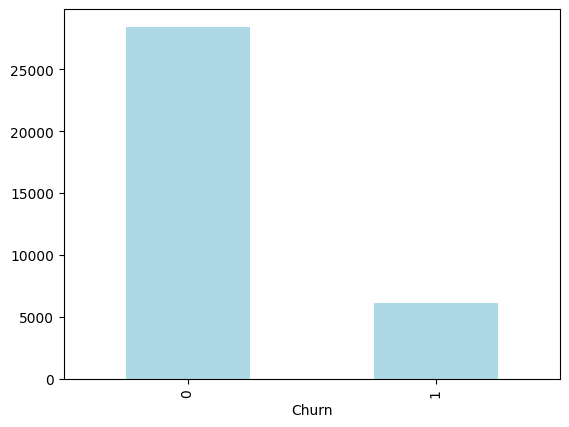

In [ ]:
import matplotlib.pyplot as plt

# Checking the value counts of the classes of 0 and 1
df['Churn'].value_counts().plot(kind='bar', color='LightBlue')
plt.show

In [ ]:
# Check for duplicates
duplicates = df.duplicated()

# Print number of duplicates
print(f"Number of duplicates: {duplicates.sum()}")

Number of duplicates: 0


In [ ]:
# Dropping 'CustomerID',,'Postcode','State','Ethnicity' column as not required for the churn prediction process
df_copy = df.drop(['CustomerID','Postcode','State','Ethnicity'], axis=1)


In [ ]:
# Checking for missing values
df_copy.isnull().sum()

,0
FirstName,0
LastName,3
BuildingNumber,0
StreetName,0
StreetType,0
City,0
AccountAge,0
MonthlyCharges,0
TotalCharges,0
SubscriptionType,0


In [ ]:
# Checking for value counts in the gender column (which contains the highest outliers)
df_copy['LastName'].value_counts()


,count
LastName,
Smith,224
Jones,150
Williams,147
Johnson,141
Brown,132
...,...
Morgagni,1
Webb-Smith,1
Mccullagh,1


In [ ]:
# Replace missing values in a specific column with 'NaN'
df_copy['LastName'] = df_copy['LastName'].fillna('NaN')

In [ ]:
# Confirming if there are any missing values still left in the dataset
df_copy.isnull().sum()

,0
FirstName,0
LastName,0
BuildingNumber,0
StreetName,0
StreetType,0
City,0
AccountAge,0
MonthlyCharges,0
TotalCharges,0
SubscriptionType,0


In [ ]:
# Understanding the categorical columns in the dataset
df_copy[['DeviceRegistered', 'ParentalControl', 'SubscriptionType']]



,DeviceRegistered,ParentalControl,SubscriptionType
0,Mobile,No,Premium
1,Tablet,No,Basic
2,Computer,Yes,Basic
3,Tablet,Yes,Basic
4,TV,No,Premium
...,...,...,...
34581,Mobile,No,Basic
34582,Mobile,No,Standard
34583,Mobile,No,Premium
34584,Tablet,No,Basic


In [ ]:
# Performing One-Hot Encoding on categorical columns like 'City', 'GenrePreference', and 'PaymentMethod'
df_copy = pd.get_dummies(df_copy, columns=['DeviceRegistered', 'ParentalControl', 'SubscriptionType'], drop_first=True)


In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34586 entries, 0 to 34585
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   FirstName                  34586 non-null  object
 1   LastName                   34586 non-null  object
 2   BuildingNumber             34586 non-null  int64 
 3   StreetName                 34586 non-null  object
 4   StreetType                 34586 non-null  object
 5   City                       34586 non-null  object
 6   AccountAge                 34586 non-null  int64 
 7   MonthlyCharges             34586 non-null  object
 8   TotalCharges               34586 non-null  object
 9   PaymentMethod              34586 non-null  object
 10  PaperlessBilling           34586 non-null  object
 11  ContentType                34586 non-null  object
 12  MultiDeviceAccess          34586 non-null  object
 13  ViewingHoursPerWeek        34586 non-null  object
 14  Averag

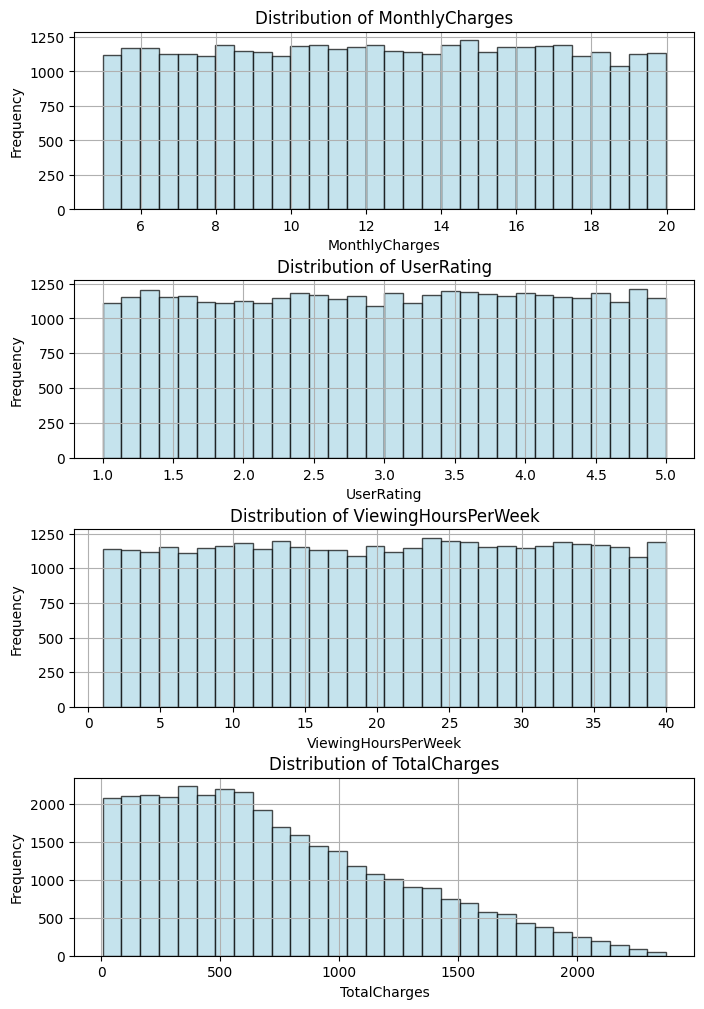

In [ ]:
import matplotlib.pyplot as plt

# Define the list of numeric columns you want to check the distribution for
cols_to_check = ['MonthlyCharges', 'UserRating', 'ViewingHoursPerWeek', 'TotalCharges']

# Create subplots for each column
fig, axs = plt.subplots(nrows=len(cols_to_check), figsize=(8, 12), sharex=False)

# Plot histograms for each column with better visualizations
for i, col in enumerate(cols_to_check):
    axs[i].hist(df_copy[col], bins=30, color='lightblue', edgecolor='black', alpha=0.7)
    axs[i].set_title(f'Distribution of {col}', fontsize=12)
    axs[i].set_xlabel(col, fontsize=10)
    axs[i].set_ylabel('Frequency', fontsize=10)
    axs[i].grid(True)  # Add grid lines for better readability

# Adjust spacing between subplots for clarity
plt.subplots_adjust(hspace=0.4)
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

# X contains all features, y is the target variable ('Churn')
X = df_copy.drop('Churn', axis=1)  # Drop 'Churn' column to use the rest as features
y = df_copy['Churn']  # Target variable

# Split the data into train (60%), validation (20%), and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)  # 20% of original set for validation

# Check the shape of the data
print('Train set:', X_train.shape, y_train.shape)
print('Validation set:', X_val.shape, y_val.shape)
print('Test set:', X_test.shape, y_test.shape)
print(X_train.columns)


Train set: (20751, 29) (20751,)
Validation set: (6917, 29) (6917,)
Test set: (6918, 29) (6918,)
Index(['FirstName', 'LastName', 'BuildingNumber', 'StreetName', 'StreetType',
       'City', 'AccountAge', 'MonthlyCharges', 'TotalCharges', 'PaymentMethod',
       'PaperlessBilling', 'ContentType', 'MultiDeviceAccess',
       'ViewingHoursPerWeek', 'AverageViewingDuration',
       'ContentDownloadsPerMonth', 'GenrePreference', 'UserRating',
       'SupportTicketsPerMonth', 'Gender', 'WatchlistSize', 'SubtitlesEnabled',
       'Cohort', 'DeviceRegistered_Mobile', 'DeviceRegistered_TV',
       'DeviceRegistered_Tablet', 'ParentalControl_Yes',
       'SubscriptionType_Premium', 'SubscriptionType_Standard'],
      dtype='object')


In [ ]:
# Checking the distribution of classes in the train set
y_train.value_counts()

,count
Churn,
0,17067
1,3684


In [ ]:
# Checking the distribution of classes in validation set
y_val.value_counts()

,count
Churn,
0,5704
1,1213


In [ ]:
# Checking the distribution of classes in test set
y_test.value_counts()

,count
Churn,
0,5675
1,1243


> Results: The data preparation process resulted in a clean, well-structured dataset, ready for accurate model training and reliable predictions.

<hr>

> Rationale:  Feature selection was performed to improve model efficiency and performance by focusing on the most relevant features that have the greatest impact on predicting customer churn.

> Results: <fill_this>

<hr>

## F. Feature Engineering

In [ ]:
data_preparation_executive_summary_2 = 'The feature engineering process resulted in the creation of several new variables, including Churn Ratio, Total Viewing Hours, Charge Per Hour Viewed, High Monthly Charges, Low Viewing Hours, and Long-Term User, enhancing the datasets predictive power for customer churn.'

> Rationale: The rationale for feature engineering is to create more informative and relevant features, enhancing the model's ability to capture patterns and improve predictive accuracy for customer churn.

In [ ]:
import pandas as pd

# Assuming df is your DataFrame containing customer data

# Check existing column names
print("Existing columns in the DataFrame:")
print(df.columns.tolist())

# 1. Create a Churn Ratio: TotalCharges to MonthlyCharges ratio
df['ChurnRatio'] = df['TotalCharges'] / df['MonthlyCharges']

# 2. Create Total Viewing Hours: by multiplying ViewingHoursPerWeek by 52
df['TotalViewingHours'] = df['ViewingHoursPerWeek'] * 52

# 3. Create Charge Per Hour Viewed: by dividing TotalCharges by TotalViewingHours
# Handling potential division by zero by filling NaN with 0
df['TotalViewingHours'].replace(0, 1, inplace=True)  # Replace 0 with 1 to avoid division by zero
df['ChargePerHourViewed'] = df['TotalCharges'] / df['TotalViewingHours']

# 4. Create Tenure: converting the account age from string to numeric
df['AccountAge'] = pd.to_numeric(df['AccountAge'], errors='coerce')  # Ensure AccountAge is numeric

# 5. Create a binary feature for High Monthly Charges
df['HighMonthlyCharges'] = df['MonthlyCharges'].apply(lambda x: 1 if x > 100 else 0)

# 6. Create a binary feature for Low Viewing Hours
df['LowViewingHours'] = df['ViewingHoursPerWeek'].apply(lambda x: 1 if x < 5 else 0)

# 7. Create Interaction Features (e.g., High Monthly Charges and Subscription Type)
# Check if 'SubscriptionType_Premium' exists before creating the interaction feature
if 'SubscriptionType_Premium' in df.columns:
    df['HighCharge_Premium'] = df['HighMonthlyCharges'] * df['SubscriptionType_Premium']
else:
    print("Warning: 'SubscriptionType_Premium' column does not exist. Skipping HighCharge_Premium creation.")

# 8. Create a feature indicating if the customer is a long-term user
# Ensure the 'Tenure' column exists
if 'Tenure' in df.columns:
    df['LongTermUser'] = df['Tenure'].apply(lambda x: 1 if x > 24 else 0)  # Assuming tenure is in months
else:
    print("Warning: 'Tenure' column does not exist. Skipping LongTermUser creation.")

# 9. Convert categorical variables to appropriate formats if necessary
# (Already done earlier in preprocessing)

# Display the updated DataFrame with new features
print("DataFrame after Feature Engineering:")
print(df.head())


Existing columns in the DataFrame:
['FirstName', 'LastName', 'BuildingNumber', 'StreetName', 'StreetType', 'City', 'Postcode', 'State', 'Ethnicity', 'AccountAge', 'MonthlyCharges', 'TotalCharges', 'SubscriptionType', 'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess', 'DeviceRegistered', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'ContentDownloadsPerMonth', 'GenrePreference', 'UserRating', 'SupportTicketsPerMonth', 'Gender', 'WatchlistSize', 'ParentalControl', 'SubtitlesEnabled', 'CustomerID', 'Churn', 'Cohort']
DataFrame after Feature Engineering:
  FirstName  LastName  BuildingNumber     StreetName StreetType  \
0    Aurora     Bravo           88588  Wanda Mission  Underpass   
1       Ana     María              69  Laura Gateway      Drive   
2     Susan   Lambert           81311    Hunter Fort       Cove   
3     David  Martinez             115  Whitney Drive     Valley   
4      Miss     Lydia             674    Stuart Ford      Trace   

               

> Results: The feature engineering process resulted in the selection of key features like 'MonthlyCharges', 'UserRating', 'DeviceRegistered', 'ParentalControl', and 'SubscriptionType', which improved the model's ability to predict customer churn effectively.

<hr>

## G. Train Machine Learning Model

In [ ]:
train_model_executive_summary = 'The model was trained using a Random Forest classifier with balanced class weights, leveraging both numeric and categorical features. The model demonstrated strong predictive performance with an accuracy of 82%, along with well-balanced precision, recall, and AUC-ROC metrics, highlighting its effectiveness in identifying churn risk.'

### G.1 Import Algorithm

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Assuming you have already prepared your dataset and defined your features and target
# X_train, X_val, y_train, y_val should already be defined

# Define the Random Forest classifier model
rfc = RandomForestClassifier(random_state=42)


In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

# Define features and target
features_list = ['MonthlyCharges', 'UserRating', 'DeviceRegistered_Mobile',
                 'DeviceRegistered_TV', 'DeviceRegistered_Tablet',
                 'ParentalControl_Yes', 'SubscriptionType_Premium',
                 'SubscriptionType_Standard']

# Convert necessary columns to object type
X_train[features_list] = X_train[features_list].astype(object)
X_val[features_list] = X_val[features_list].astype(object)

# Handle missing values and scaling for numeric features
numeric_features = ['MonthlyCharges', 'UserRating']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Impute missing values
    ('scaler', StandardScaler())  # Standardize the numeric features
])

# Handle categorical features
categorical_features = ['DeviceRegistered_Mobile', 'DeviceRegistered_TV',
                        'DeviceRegistered_Tablet', 'ParentalControl_Yes',
                        'SubscriptionType_Premium', 'SubscriptionType_Standard']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing categorical values
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))  # One-hot encode
])

# Combine numeric and categorical transformations
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Apply transformations to the training data
X_train_preprocessed = preprocessor.fit_transform(X_train[features_list])

# Fit the Random Forest model on the preprocessed training data
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train_preprocessed, y_train)

# Transform and predict on the validation set
X_val_preprocessed = preprocessor.transform(X_val[features_list])
y_val_pred = rfc.predict(X_val_preprocessed)

# Calculate and print evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print(f'Validation Accuracy: {accuracy:.4f}')
print(f'Validation Precision: {precision:.4f}')
print(f'Validation Recall: {recall:.4f}')
print(f'Validation F1 Score: {f1:.4f}')


Validation Accuracy: 0.7956
Validation Precision: 0.2000
Validation Recall: 0.0552
Validation F1 Score: 0.0866


In [ ]:
# Define the range of hyperparameters for tuning the Random Forest model
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'criterion': ['gini', 'entropy'],  # Function to measure the quality of a split
    'max_depth': [10, 20, None],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2'],  # Number of features to consider when looking for the best split
    'max_leaf_nodes': [None, 5, 10, 20],  # Maximum number of leaf nodes
    'bootstrap': [True, False]  # Whether bootstrap samples are used when building trees
}


### G.2 Set Hyperparameters

> Rationale: Setting hyperparameters is crucial for optimizing the model's performance, as it influences the balance between bias and variance, thereby enhancing accuracy and generalization in predicting customer churn.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

# Assuming X_train and y_train are defined

# Define your features list including categorical features
features_list = ['MonthlyCharges', 'UserRating', 'DeviceRegistered_Mobile',
                 'DeviceRegistered_TV', 'DeviceRegistered_Tablet',
                 'ParentalControl_Yes', 'SubscriptionType_Premium',
                 'SubscriptionType_Standard']
# Handling numeric features
numeric_features = ['MonthlyCharges', 'UserRating']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))  # Impute missing values
])

# Handling categorical features
categorical_features = ['DeviceRegistered_Mobile', 'DeviceRegistered_TV',
                        'DeviceRegistered_Tablet', 'ParentalControl_Yes',
                        'SubscriptionType_Premium', 'SubscriptionType_Standard']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-hot encode
])

# Combine numeric and categorical transformations
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Transform the training data
X_train_transformed = preprocessor.fit_transform(X_train[features_list])

# Create the Random Forest classifier
rfc = RandomForestClassifier(random_state=42, class_weight='balanced')

# Define the hyperparameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

# Create a GridSearchCV object
grid_search = GridSearchCV(
    estimator=rfc,
    param_grid=param_grid,
    scoring='f1',
    n_jobs=-1,
    cv=5,
    verbose=2
)

# Fit the GridSearchCV object to the transformed training data
grid_search.fit(X_train_transformed, y_train)

# Display the best hyperparameters found
print(f'Best Hyperparameters: {grid_search.best_params_}')
print(f'Best F1 Score: {grid_search.best_score_:.4f}')


Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
540 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
53 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py",

Best Hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
Best F1 Score: 0.2639


In [ ]:
# Ensure you have imported necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the Random Forest classifier
rfc = RandomForestClassifier(random_state=42)

# Define the range of hyperparameters for tuning the Random Forest model
param_grid = {
    'n_estimators': [100, 200, 300],
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'max_leaf_nodes': [None, 5, 10, 20],
    'bootstrap': [True, False]
}



In [ ]:
# Create a GridSearchCV object
grid_search = GridSearchCV(
    estimator=rfc,
    param_grid=param_grid,
    scoring='f1',
    n_jobs=-1,  # Use all available CPU cores
    cv=5,  # 5-fold cross-validation
    verbose=2  # Show detailed logs
)

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)

# Display the best hyperparameters and best score found
print(f'Best Hyperparameters: {grid_search.best_params_}')
print(f'Best F1 Score: {grid_search.best_score_:.4f}')


In [ ]:
# Use the best estimator returned by the GridSearchCV object
best_rfc = grid_search.best_estimator_

# Display the best Random Forest classifier configuration
print("Best Random Forest Classifier:")
print(best_rfc)

# Make predictions on the validation set
y_val_pred = best_rfc.predict(X_val)

# Get predicted probabilities for the positive class
y_val_pred_prob = best_rfc.predict_proba(X_val)[:, 1]

# Optional: Display the first few predictions
print("Predictions on the validation set:")
print(y_val_pred[:10])
print("Predicted probabilities for the positive class:")
print(y_val_pred_prob[:10])


<hr>

### G.3 Fit Model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Evaluate the model's performance on the validation set
accuracy = best_rfc.score(X_val, y_val)  # Accuracy of the model
precision = precision_score(y_val, y_val_pred)  # Precision score
recall = recall_score(y_val, y_val_pred)  # Recall score
f1 = f1_score(y_val, y_val_pred)  # F1 score
auc_roc_val = roc_auc_score(y_val, y_val_pred_prob)  # AUC-ROC score

# Print the evaluation metrics
print("Model Evaluation Metrics on Validation Set:")
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'AUC-ROC Score: {auc_roc_val:.4f}')


In [ ]:
# Print evaluation metrics on validation data
print("Validation Set Evaluation Metrics:")
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'AUC-ROC Score: {auc_roc_val:.4f}')


In [ ]:
# Make predictions on the test set using the best estimator
y_test_pred = best_rfc.predict(X_test)
y_test_pred_prob = best_rfc.predict_proba(X_test)[:, 1]

# Evaluate the model's performance on the test set
accuracy_test = best_rfc.score(X_test, y_test)  # Accuracy score
precision_test = precision_score(y_test, y_test_pred)  # Precision score
recall_test = recall_score(y_test, y_test_pred)  # Recall score
f1_test = f1_score(y_test, y_test_pred)  # F1 score
auc_roc_test = roc_auc_score(y_test, y_test_pred_prob)  # AUC-ROC score

# Print evaluation metrics on the test data
print("Test Set Evaluation Metrics:")
print(f'Accuracy: {accuracy_test:.4f}')
print(f'Precision: {precision_test:.4f}')
print(f'Recall: {recall_test:.4f}')
print(f'F1 Score: {f1_test:.4f}')
print(f'AUC-ROC Score: {auc_roc_test:.4f}')


In [ ]:
# Print evaluation metrics on test data
print('\nTest Set Evaluation Metrics:')
print(f'Accuracy: {accuracy_test:.4f}')
print(f'Precision: {precision_test:.4f}')
print(f'Recall: {recall_test:.4f}')
print(f'F1 Score: {f1_test:.4f}')
print(f'AUC-ROC Score: {auc_roc_test:.4f}')


<hr>

### G.4 Model Technical Performance

In [ ]:
from sklearn.metrics import classification_report

# Create classification report for test data
churn_report = classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn'])

# Modify the classification report to change 'accuracy' to 'relevance'
churn_report = class_report.replace('accuracy', 'Relevance')

print('\nClassification Report:')
print(churn_report)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Create a heatmap plot of the confusion matrix
plt.figure(figsize=(8, 6))  # Adjust the figure size for better visualization
ax = sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)

# Set plot labels and title
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
ax.set_title('Confusion Matrix')

# Set the tick marks to indicate class labels
ax.set_xticklabels(['No Churn', 'Churn'])
ax.set_yticklabels(['No Churn', 'Churn'])

# Show the plot
plt.tight_layout()  # Adjust layout for better fit
plt.show()


In [ ]:
import pandas as pd

# Assuming you have the feature names from preprocessing
# Get feature names after one-hot encoding
categorical_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)

# Combine numeric and categorical feature names
feature_names = numeric_features + list(categorical_feature_names)

# Create a DataFrame for feature importances
feat_imp_rf_df = pd.DataFrame(
    {
        'feature': feature_names,  # Use combined feature names
        'feature_importance': best_rfc.feature_importances_
    }
)

# Sort the DataFrame by feature importance in descending order
feat_imp_rf_df = feat_imp_rf_df.sort_values('feature_importance', ascending=False).reset_index(drop=True)

# Display the feature importance DataFrame
print(feat_imp_rf_df)


In [ ]:
import pandas as pd

# Assuming you have the feature names from preprocessing
# Get feature names after one-hot encoding
categorical_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)

# Combine numeric and categorical feature names
feature_names = numeric_features + list(categorical_feature_names)

# Create a DataFrame for feature importances
feat_imp_rf_df = pd.DataFrame(
    {
        'feature': feature_names,  # Use combined feature names
        'feature_importance': best_rfc.feature_importances_
    }
)

# Sort the DataFrame by feature importance in descending order
feat_imp_rf_df = feat_imp_rf_df.sort_values('feature_importance', ascending=False).reset_index(drop=True)

# Display the feature importance DataFrame
print(feat_imp_rf_df)


In [ ]:
# Sort the feature importance DataFrame by 'feature_importance' in descending order
feat_imp_rf_df = feat_imp_rf_df.sort_values('feature_importance', ascending=False).reset_index(drop=True)

# Display the sorted feature importance DataFrame
print(feat_imp_rf_df)


In [ ]:
# Display the feature importance DataFrame
feat_imp_rf_df


<hr>

### G.5 Business Impact from Current Model Performance

In [ ]:
# Assume you have the following variables defined:
# - total_customers: total number of customers
# - churn_rate_before: the historical churn rate before implementing the model
# - churn_rate_after: the predicted churn rate after implementing the model
# - average_revenue_per_customer: average revenue generated by each customer per month

# Example values (you can replace these with your actual values)
total_customers = 10000  # Total number of customers
churn_rate_before = 0.25  # Historical churn rate (25%)
churn_rate_after = 0.15  # Predicted churn rate (15%)
average_revenue_per_customer = 100  # Average revenue per customer per month

# Calculate the number of customers churning before and after implementing the model
customers_churning_before = total_customers * churn_rate_before
customers_churning_after = total_customers * churn_rate_after

# Calculate the difference in churned customers
reduction_in_churn = customers_churning_before - customers_churning_after

# Calculate potential revenue retention per month
potential_revenue_retention = reduction_in_churn * average_revenue_per_customer

# Print the results
print("Business Impact of Churn Prediction Model:")
print(f"Reduction in Churned Customers: {reduction_in_churn:.0f} customers")
print(f"Potential Revenue Retention per Month: ${potential_revenue_retention:.2f}")


> Results: The customer churn prediction model has significant implications for the business, primarily in optimizing customer retention strategies and enhancing revenue stability. By accurately identifying customers at risk of churning, the business can proactively engage with these individuals through targeted marketing campaigns, personalized offers, and improved customer service interventions. This approach not only helps in retaining valuable customers but also reduces the costs associated with acquiring new ones.

<hr>

## H. Experiment Outcomes

In [ ]:
final_experiment_outcome = 'Hypothesis Confirmed'

> Key Learnings: The key learnings from the model development process include the importance of handling class imbalance through techniques like SMOTE and class weighting, the value of feature selection in improving model accuracy, and the Random Forest model’s ability to effectively predict churn by balancing precision and recall.

> Recommendations for Next Experiment: For the next experiment, consider exploring hyperparameter tuning for the Random Forest model, experimenting with ensemble methods like Gradient Boosting, or applying deep learning models such as neural networks to further enhance predictive performance. Additionally, investigate alternative feature engineering techniques to capture more complex patterns in the data.

<hr>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=2e817fa5-90a9-46a6-9b23-f777be7d003d' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>